In [34]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [35]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


X_full, y_full = make_moons(n_samples=1000, noise=0.6) 
X_train, X_test_valid, y_train, y_test_valid = train_test_split(X_full, y_full, test_size=0.3, random_state=39)
X_test, X_valid, y_test, y_valid = train_test_split(X_test_valid, y_test_valid, test_size=0.5, random_state=39)



In [36]:
from sklearn.model_selection import GridSearchCV


model = BaggingClassifier(
  DecisionTreeClassifier(), n_estimators=500,
  max_samples=100, bootstrap=True, n_jobs=1
)


parameter_grid = {
  "n_estimators" : [100, 200, 300, 400, 500],
  "max_samples" : [50, 100, 200, 500],
}

grid_search = GridSearchCV(model, param_grid=parameter_grid, cv=5, refit=True, return_train_score=True)
grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_


KeyboardInterrupt: 

In [ ]:
score = grid_search.score(X_test, y_test)
print("Score: {:.2f}".format(score))
print(grid_search.best_estimator_)

Score: 0.79
BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=50,
                  n_estimators=500, n_jobs=1)


In [ ]:
decisionTree = DecisionTreeClassifier()
decisionTree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


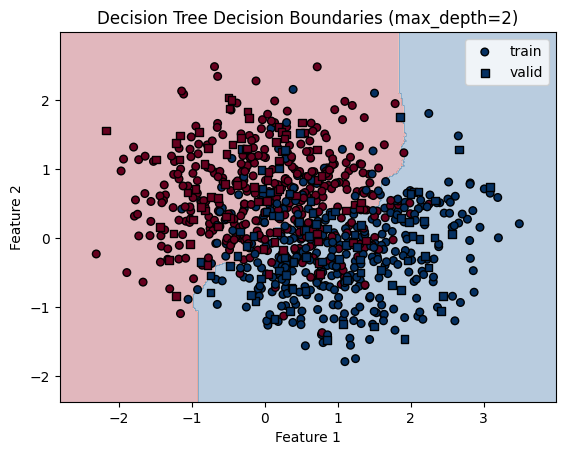

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# grid for plotting
x_min, x_max = X_full[:, 0].min() - 0.5, X_full[:, 0].max() + 0.5
y_min, y_max = X_full[:, 1].min() - 0.5, X_full[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# plot training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.RdBu, s=30, label="train")
plt.scatter(X_valid[:, 0], X_valid[:, 1], c=y_valid, edgecolor="k", cmap=plt.cm.RdBu, s=30, marker="s", label="valid")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundaries (max_depth=2)")
plt.legend()
plt.show()


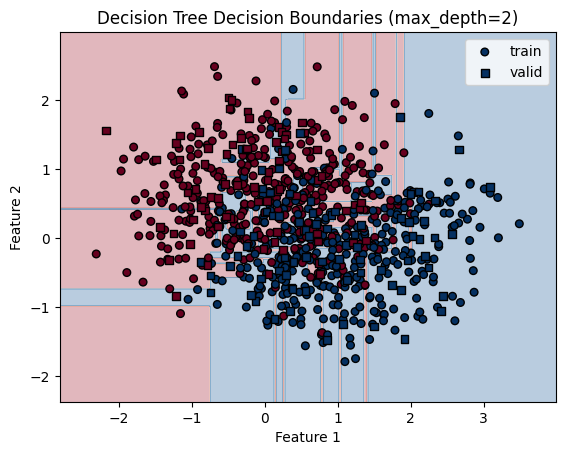

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# grid for plotting
x_min, x_max = X_full[:, 0].min() - 0.5, X_full[:, 0].max() + 0.5
y_min, y_max = X_full[:, 1].min() - 0.5, X_full[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = decisionTree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# plot training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.RdBu, s=30, label="train")
plt.scatter(X_valid[:, 0], X_valid[:, 1], c=y_valid, edgecolor="k", cmap=plt.cm.RdBu, s=30, marker="s", label="valid")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundaries (max_depth=2)")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred_tree = decisionTree.predict(X_test)
y_pred_bagging = model.predict(X_test)

# Accuracy
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_tree))
print("Bagging accuracy:", accuracy_score(y_test, y_pred_bagging))

# Full report
print("Decision Tree report:\n", classification_report(y_test, y_pred_tree))
print("Bagging report:\n", classification_report(y_test, y_pred_bagging))

Decision Tree accuracy: 0.64
Bagging accuracy: 0.7866666666666666
Decision Tree report:
               precision    recall  f1-score   support

           0       0.64      0.64      0.64        75
           1       0.64      0.64      0.64        75

    accuracy                           0.64       150
   macro avg       0.64      0.64      0.64       150
weighted avg       0.64      0.64      0.64       150

Bagging report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80        75
           1       0.83      0.72      0.77        75

    accuracy                           0.79       150
   macro avg       0.79      0.79      0.79       150
weighted avg       0.79      0.79      0.79       150

